Изображение загружено: 474x713 пикселей
   Найдено K = 11
   PSNR (mean): 20.16
   PSNR (median): 19.89

Ответ: минимальное K с PSNR > 20 = 11


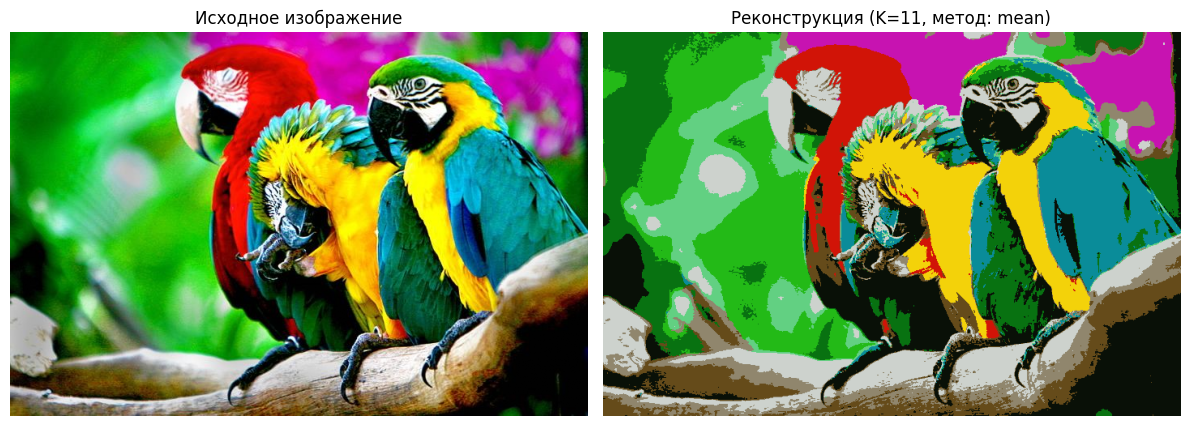

In [ ]:
# Импорты
%matplotlib inline
%skimage inline

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from sklearn.cluster import KMeans


# 1. Загрузка изображения
image = img_as_float(io.imread('data/parrots.jpg'))  # shape: (H, W, 3)
height, width, _ = image.shape
X = image.reshape(-1, 3)  # (N_pixels, 3)

print(f"Изображение загружено: {height}x{width} пикселей")


# Функция PSNR
def psnr(image_true, image_test, data_range=1.0):
    mse = np.mean((image_true - image_test) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((data_range ** 2) / mse)


# 2. Перебор K от 1 до 20
best_k = None
best_reconstructed = None
best_method = None

for k in range(1, 21):
    # Обучение K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=241, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    # Способ 1: среднее 
    img_mean = centers[labels].reshape(height, width, 3)
    psnr_mean = psnr(image, img_mean)

    # Способ 2: медиана
    img_median = np.zeros_like(X)
    for cluster_id in range(k):
        mask = (labels == cluster_id)
        if np.any(mask):
            median_color = np.median(X[mask], axis=0)
            img_median[mask] = median_color
    img_median = img_median.reshape(height, width, 3)
    psnr_median = psnr(image, img_median)

    # Проверка условия
    if psnr_mean > 20 or psnr_median > 20:
        best_k = k
        best_method = 'mean' if psnr_mean > psnr_median else 'median'
        best_reconstructed = img_mean if psnr_mean > psnr_median else img_median
        print(f"   Найдено K = {k}")
        print(f"   PSNR (mean): {psnr_mean:.2f}")
        print(f"   PSNR (median): {psnr_median:.2f}")
        break


# 3. Вывод результата
if best_k is not None:
    print(f"\nОтвет: минимальное K с PSNR > 20 = {best_k}")
    
    # Отображение изображений
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Исходное изображение")
    plt.imshow(image)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Реконструкция (K={best_k}, метод: {best_method})")
    plt.imshow(np.clip(best_reconstructed, 0, 1))  # clip для защиты от вылетов
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено K ≤ 20 с PSNR > 20")